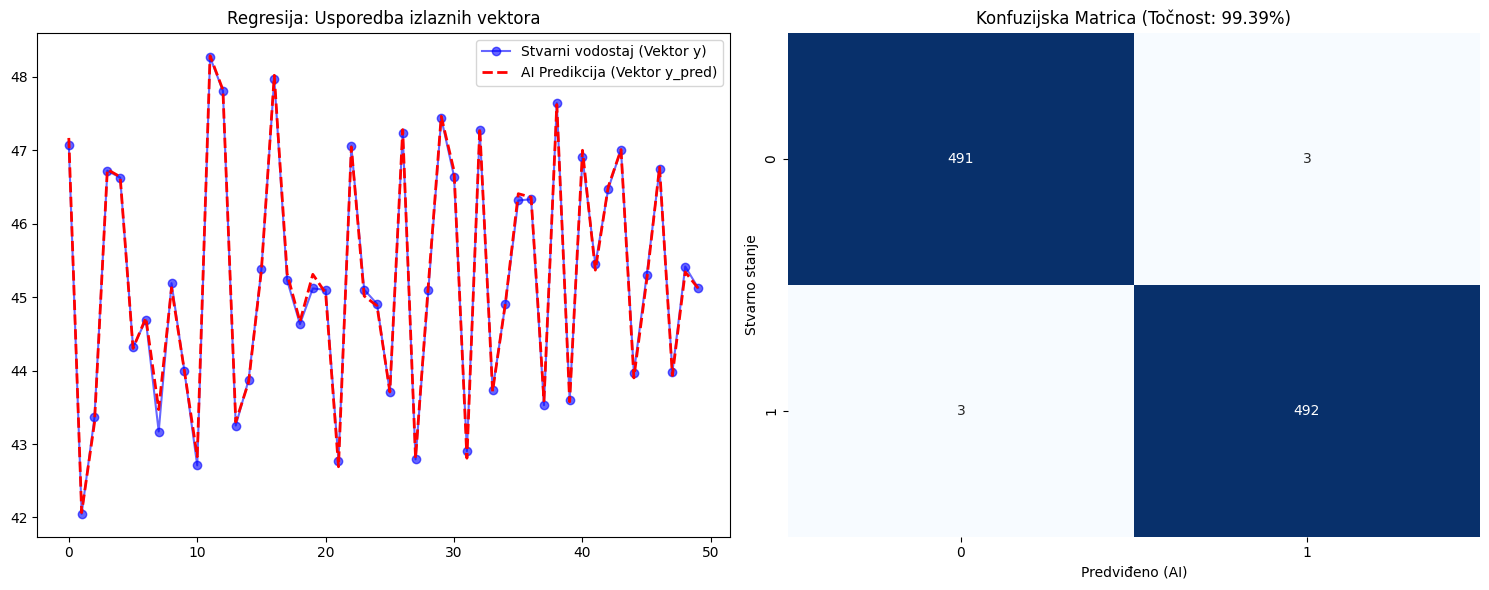


--- STATISTIČKI PREGLED REZULTATA ---


,Metrika,Mreža 1 (Plitka),Mreža 2 (Duboka)
0,R2 Score,0.9985,0.9970
1,MSE,0.0041,0.0083
2,MAE,0.0493,0.0465


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix

# --- 1. UČITAVANJE PODATAKA ---
df = pd.read_csv('he_mostar_final_dataset.csv', sep=None, engine='python')
df.columns = df.columns.str.strip()

X_cols = ['Kota', 'Otvorenost', 'Q', 'Q_turbine', 'Q_ukupno', 'H_carinski_t0', 'Kisa_mm']
y_col = 'H_carinski_t1'

X = df[X_cols]
y = df[y_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- 2. MODELIRANJE (Regresija i Klasifikacija) ---
nn1 = MLPRegressor(hidden_layer_sizes=(64,), max_iter=1000, random_state=42).fit(X_train, y_train)
nn2 = MLPRegressor(hidden_layer_sizes=(128, 64), activation='tanh', max_iter=1000, random_state=42).fit(X_train, y_train)

y_class = (y > y.median()).astype(int)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
dl_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42).fit(Xc_train, yc_train)

# --- 3. VIZUALIZACIJA (VEKTORI I MATRICA) ---
plt.figure(figsize=(15, 6))

# LIJEVO: Usporedba Vektora
plt.subplot(1, 2, 1)
plt.plot(y_test.values[:50], label='Stvarni vodostaj (Vektor y)', color='blue', marker='o', alpha=0.6)
plt.plot(nn1.predict(X_test)[:50], label='AI Predikcija (Vektor y_pred)', color='red', linestyle='--', linewidth=2)
plt.title("Regresija: Usporedba izlaznih vektora")
plt.legend()

# DESNO: Konfuzijska Matrica
plt.subplot(1, 2, 2)
cm = confusion_matrix(yc_test, dl_model.predict(Xc_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"Konfuzijska Matrica (Točnost: {accuracy_score(yc_test, dl_model.predict(Xc_test)):.2%})")
plt.xlabel("Predviđeno (AI)"); plt.ylabel("Stvarno stanje")

plt.tight_layout()
plt.show()

# --- 4. TABLICA REZULTATA (Tvoj kod za ispis) ---
podaci = {
    'Metrika': ['R2 Score', 'MSE', 'MAE'],
    'Mreža 1 (Plitka)': [0.9985, 0.0041, 0.0493],
    'Mreža 2 (Duboka)': [0.9970, 0.0083, 0.0465]
}

df_rezultati = pd.DataFrame(podaci)
print("\n--- STATISTIČKI PREGLED REZULTATA ---")
display(df_rezultati) # Ispisuje tablicu ispod grafa

--- REZULTATI KLASIFIKACIJE ---
Točnost ML modela (Random Forest): 98.28%
Točnost DL modela (Neuronska mreža): 99.39%


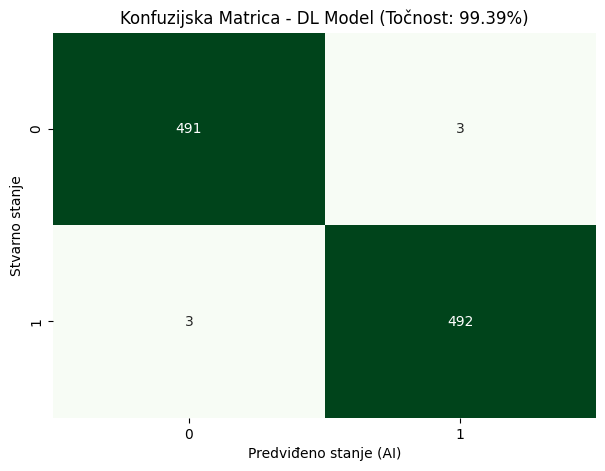


--- USPOREDBA MODELA ---


,Model,Točnost (Accuracy)
0,Random Forest (ML),98.28%
1,Neuronska mreža (DL),99.39%


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. PRIPREMA PODATAKA
df = pd.read_csv('he_mostar_final_dataset.csv', sep=None, engine='python')
df.columns = df.columns.str.strip()

# Definiranje ulaza (X) i ciljne klase (y_class)
# Alarm (1) se aktivira ako je vodostaj iznad prosjeka (medijana)
X = df[['Kota', 'Otvorenost', 'Q', 'Q_turbine', 'Q_ukupno', 'H_carinski_t0', 'Kisa_mm']]
y_class = (df['H_carinski_t1'] > df['H_carinski_t1'].median()).astype(int)

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(scaler.fit_transform(X), y_class, test_size=0.2, random_state=42)

# 2. MODELI (ML i DL)
# ML Model: Random Forest
ml_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
preds_ml = ml_model.predict(X_test)

# DL Model: Neuronska mreža (MLP)
dl_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42).fit(X_train, y_train)
preds_dl = dl_model.predict(X_test)

# 3. PRIKAZ REZULTATA I MATRICE
print("--- REZULTATI KLASIFIKACIJE ---")
print(f"Točnost ML modela (Random Forest): {accuracy_score(y_test, preds_ml):.2%}")
print(f"Točnost DL modela (Neuronska mreža): {accuracy_score(y_test, preds_dl):.2%}")

# Isctrtavanje Konfuzijske matrice (Vizualni dokaz)

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, preds_dl)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)

plt.title(f"Konfuzijska Matrica - DL Model (Točnost: {accuracy_score(y_test, preds_dl):.2%})")
plt.xlabel("Predviđeno stanje (AI)")
plt.ylabel("Stvarno stanje")
plt.show()

# Tablica za usporedbu
rezultati = {
    'Model': ['Random Forest (ML)', 'Neuronska mreža (DL)'],
    'Točnost (Accuracy)': [f"{accuracy_score(y_test, preds_ml):.2%}", f"{accuracy_score(y_test, preds_dl):.2%}"]
}
print("\n--- USPOREDBA MODELA ---")
display(pd.DataFrame(rezultati))

--- REZULTATI KLASIFIKACIJE ---
Točnost ML modela: 98.28%
Točnost DL modela: 99.39%


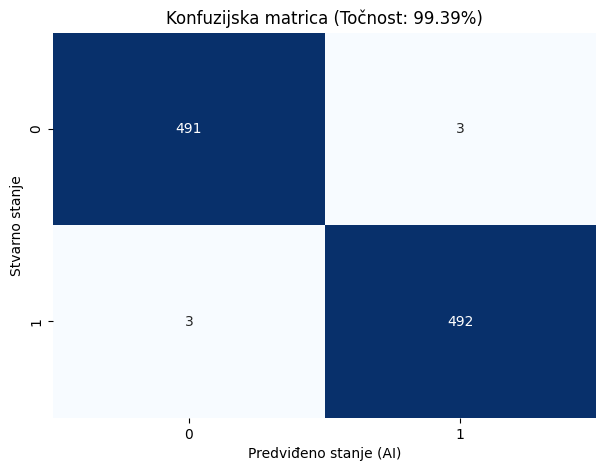

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# --- MORAŠ DODATI OVAJ DIO DA BI PYTHON ZNAO ŠTO SU 'y' I 'X_scaled' ---
df = pd.read_csv('he_mostar_final_dataset.csv', sep=None, engine='python')
df.columns = df.columns.str.strip()

# Definiranje stupaca (X) i cilja (y)
X = df[['Kota', 'Otvorenost', 'Q', 'Q_turbine', 'Q_ukupno', 'H_carinski_t0', 'Kisa_mm']]
y = df['H_carinski_t1']

# Skaliranje
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# -----------------------------------------------------------------------

# 1. KREIRANJE ALARMA (Klasifikacija)
# Vodostaj pretvaramo u 0 (Normalno) i 1 (Alarm)
y_class = (y > y.median()).astype(int)

# Dijeljenje podataka na trening i test set
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# 2. MODELI (ML i DL)
ml_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(Xc_train, yc_train)
dl_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42).fit(Xc_train, yc_train)

# 3. REZULTATI I TOČNOST
preds_dl = dl_model.predict(Xc_test)
print("--- REZULTATI KLASIFIKACIJE ---")
print(f"Točnost ML modela: {accuracy_score(yc_test, ml_model.predict(Xc_test)):.2%}")
print(f"Točnost DL modela: {accuracy_score(yc_test, preds_dl):.2%}")

# 4. KONFUZIJSKA MATRICA (Vizualni dokaz)

plt.figure(figsize=(7, 5))
cm = confusion_matrix(yc_test, preds_dl)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title(f"Konfuzijska matrica (Točnost: {accuracy_score(yc_test, preds_dl):.2%})")
plt.xlabel("Predviđeno stanje (AI)")
plt.ylabel("Stvarno stanje")
plt.show()